# Inventory Analysis

## Overview

...

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
from pathlib import Path

## 1. Import Data

### 1a. Define data paths

Use the imported Path function to create relative paths to data files.

In [2]:
DATA_FOLDER_PATH = Path("../data")
DATA_1_PATH = DATA_FOLDER_PATH / "diapers.csv"
DATA_2_PATH = DATA_FOLDER_PATH / "form.csv"
DATA_3_PATH = DATA_FOLDER_PATH / "form_2_new.csv"
OUTPUT_DATA_PATH = DATA_FOLDER_PATH / "output/diapers_final.csv"

### 1b. Import data from CSV files

Use pandas to load csv files as DataFrames.

In [3]:
df1 = pd.read_csv(DATA_1_PATH)
df2 = pd.read_csv(DATA_2_PATH, header=1)
df3 = pd.read_csv(DATA_3_PATH)

## 2. Data Cleaning

Because the Google Form used for data collection changed a few times, there are 3 different csv files with varying columns that need to be combined into one csv file.

The output csv file should have the following columns:  
- timestamp (date)
- branch (string)
- zip (string)
- size (string)
- packs (int)

### 2a. File 1 - diapers.csv

Display summary information.

In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 59425 entries, 0 to 59424
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  55946 non-null  str    
 1   BRANCH     55930 non-null  str    
 2   ZIP CODE   55938 non-null  str    
 3   SIZE       52387 non-null  str    
 4   # PACKS    55793 non-null  float64
 5   SIZE.1     8397 non-null   str    
 6   # PACKS.1  9265 non-null   float64
 7   SIZE.2     1785 non-null   str    
 8   # PACKS.2  2873 non-null   float64
 9   TOTAL      59425 non-null  int64  
 10  DATE       59425 non-null  str    
 11  MONTH      55946 non-null  str    
 12  YEAR       55946 non-null  str    
 13  DAY        55946 non-null  str    
 14  WEEKDAY    55946 non-null  str    
dtypes: float64(3), int64(1), str(11)
memory usage: 6.8 MB


Select required columns.

In [5]:
df1_filtered: pd.DataFrame = df1.iloc[:, 0:9]

In [6]:
df1_filtered.head()

,Timestamp,BRANCH,ZIP CODE,SIZE,# PACKS,SIZE.1,# PACKS.1,SIZE.2,# PACKS.2
0,9/7/2021 0:00:00,GG,63011,1,3.0,NaN,NaN,NaN,NaN
1,9/7/2021 0:00:00,GG,63011,3T,2.0,NaN,NaN,NaN,NaN
2,9/14/2021 0:00:00,GG,63118,5,2.0,NaN,NaN,NaN,NaN
3,9/14/2021 0:00:00,GG,63118,6,2.0,NaN,NaN,NaN,NaN
4,9/14/2021 0:00:00,GG,63125,5,2.0,NaN,NaN,NaN,NaN


Filter date to before 2024.

In [7]:
df1_filtered['Timestamp'] = pd.to_datetime(df1_filtered['Timestamp'], errors="coerce")

In [8]:
df1_filtered = df1_filtered[df1_filtered['Timestamp'] < "1/1/2024"]

Stack rows.

In [9]:
def stack_rows(df_filtered: pd.DataFrame) -> list[list]:
    df_list = df_filtered.values.tolist()
    combined_data = []
    for record in df_list:
        for i in range(3, 9, 2):
            if record[i] != record[i] and record[i+1] != record[i+1]:
                continue
            row = [*record[0:3], *record[i:i+2]]
            combined_data.append(row)
    return combined_data

In [10]:
combined_data_1: list[list] = stack_rows(df1_filtered)

Create DataFrame.

In [11]:
def create_df(combined_data: list[list]) -> pd.DataFrame:
    columns: list = ["timestamp", "branch", "zip", "size", "packs"]
    df_final: pd.DataFrame = pd.DataFrame(combined_data, columns=columns)
    return df_final

In [12]:
df1_final: pd.DataFrame = create_df(combined_data_1)

### 2b. File 2 - form.csv

Display summary information.

In [13]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 24514 entries, 0 to 24513
Data columns (total 15 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Timestamp                                 24514 non-null  str    
 1   BRANCH                                    24514 non-null  str    
 2   ZIP CODE                                  24514 non-null  str    
 3   What are you submitting stats for?        24514 non-null  str    
 4   Size                                      19367 non-null  str    
 5   Unnamed: 5                                19367 non-null  str    
 6   Number of PACKS OF DIAPERS distributed    19367 non-null  float64
 7   Size.1                                    7267 non-null   str    
 8   Unnamed: 8                                7267 non-null   str    
 9   Number of PACKS OF DIAPERS distributed.1  7129 non-null   float64
 10  Size.2                                    156

Filter to select diaper stats only.

In [14]:
df2_diapers = df2[df2.iloc[:, 3] == "Diapers"]

Select required columns.

In [15]:
df2_col_idx = [0,1,2,4,6,7,9,10,12]
df2_filtered = df2_diapers.iloc[1:,df2_col_idx]

In [16]:
df2_filtered.head()

,Timestamp,BRANCH,ZIP CODE,Size,Number of PACKS OF DIAPERS distributed,Size.1,Number of PACKS OF DIAPERS distributed.1,Size.2,Number of PACKS OF DIAPERS distributed.2
3,1/2/2024 9:29:02,LC,63137,5,1.0,NaN,NaN,NaN,NaN
5,1/2/2024 9:38:49,LC,63136,3,1.0,4,1.0,NaN,NaN
6,1/2/2024 9:48:33,WR,63123,4T,1.0,NaN,NaN,NaN,NaN
7,1/2/2024 10:00:31,LC,62040,4,1.0,4,1.0,NaN,NaN
9,1/2/2024 10:50:17,GG,63125,2,1.0,2,1.0,3,1.0


In [17]:
df2_filtered.tail()

,Timestamp,BRANCH,ZIP CODE,Size,Number of PACKS OF DIAPERS distributed,Size.1,Number of PACKS OF DIAPERS distributed.1,Size.2,Number of PACKS OF DIAPERS distributed.2
24509,10/16/2025 14:15:23,LC,63136,6,1.0,NaN,NaN,NaN,NaN
24510,10/16/2025 14:28:33,LC,63136,N,1.0,5,1.0,NaN,NaN
24511,10/16/2025 14:48:13,NB,63136,2T,1.0,3T,1.0,NaN,2.0
24512,10/16/2025 14:46:19,NB,63107,3,1.0,NaN,NaN,NaN,1.0
24513,10/16/2025 18:13:58,LC,63137,6,1.0,NaN,NaN,NaN,NaN


Stack rows.

In [18]:
combined_data_2: list[list] = stack_rows(df2_filtered)

Create DataFrame.

In [19]:
df2_final = create_df(combined_data_2)
df2_final.head()

,timestamp,branch,zip,size,packs
0,1/2/2024 9:29:02,LC,63137,5,1.0
1,1/2/2024 9:38:49,LC,63136,3,1.0
2,1/2/2024 9:38:49,LC,63136,4,1.0
3,1/2/2024 9:48:33,WR,63123,4T,1.0
4,1/2/2024 10:00:31,LC,62040,4,1.0


### 2c. File 3 - form2.csv

Display summary information.

In [20]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 8853 entries, 0 to 8852
Data columns (total 13 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Timestamp                                                        8853 non-null   str    
 1   BRANCH                                                           8827 non-null   str    
 2   ZIP CODE                                                         8853 non-null   str    
 3   Size                                                             7490 non-null   str    
 4   Number of PACKS OF DIAPERS distributed                           7276 non-null   float64
 5   Size.1                                                           2208 non-null   str    
 6   Number of PACKS OF DIAPERS distributed.1                         2144 non-null   float64
 7   Size.2                                               

In [21]:
df3.head()

,Timestamp,BRANCH,ZIP CODE,Size,Number of PACKS OF DIAPERS distributed,Size.1,Number of PACKS OF DIAPERS distributed.1,Size.2,Number of PACKS OF DIAPERS distributed.2,Number of FLOW KITS distributed,Number of REUSABLE FLOW KITS distributed,Do you want to record distribution statistics?,Are you submitting statistics or enrolling a new diaper patron?
0,9/9/2023 8:55:18,FV,12345,0,0.0,0,0.0,0,0.0,0.0,0.0,NaN,Diaper Distribution
1,10/17/2025 8:54:37,PV,63114,4,1.0,6,1.0,NaN,NaN,NaN,NaN,NaN,Statistics (Diapers + Flow Kits)
2,10/17/2025 8:59:27,FV,63137,5,2.0,4,1.0,NaN,NaN,1.0,NaN,NaN,Statistics (Diapers + Flow Kits)
3,10/17/2025 9:00:27,WR,63125,5,1.0,6,1.0,NaN,NaN,1.0,NaN,NaN,Statistics (Diapers + Flow Kits)
4,10/17/2025 9:00:27,FV,63031,3,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,Statistics (Diapers + Flow Kits)


In [22]:
df3.tail()

,Timestamp,BRANCH,ZIP CODE,Size,Number of PACKS OF DIAPERS distributed,Size.1,Number of PACKS OF DIAPERS distributed.1,Size.2,Number of PACKS OF DIAPERS distributed.2,Number of FLOW KITS distributed,Number of REUSABLE FLOW KITS distributed,Do you want to record distribution statistics?,Are you submitting statistics or enrolling a new diaper patron?
8848,7/3/2026 8:30:40,FV,63031,7,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Statistics (Diapers + Flow Kits)
8849,7/3/2026 8:31:21,LC,63138,5,1.0,5,1.0,NaN,NaN,NaN,NaN,NaN,Statistics (Diapers + Flow Kits)
8850,7/3/2026 8:44:48,LC,63136,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,Statistics (Diapers + Flow Kits)
8851,7/3/2026 9:15:47,FV,63137,3T,1.0,2T,1.0,2T,1.0,NaN,NaN,NaN,Statistics (Diapers + Flow Kits)
8852,7/3/2026 9:32:40,WR,63123,4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Statistics (Diapers + Flow Kits)


Select required columns.

In [23]:
df3_filtered = df3.iloc[1:, 0:9]

Stack rows.

In [24]:
combined_data_3: list[list] = stack_rows(df3_filtered)

Create DataFrame.

In [25]:
df3_final = create_df(combined_data_3)

### 2d. Combining DataFrames into One

Concatenating all three DataFrames.

In [26]:
df_combined = pd.concat([df1_final, df2_final, df3_final], axis=0, ignore_index=True)

### 2e. Cleaning by Column

Display counts of na values.

In [27]:
df_combined.isna().sum()

timestamp      0
branch        21
zip            0
size         942
packs        482
dtype: int64

#### I. timestamp

Find missing row in timestamp column.

In [28]:
df_combined[df_combined["timestamp"].isna()]

,timestamp,branch,zip,size,packs


Drop row with na timestamp.

In [29]:
df_combined.drop([29164], inplace=True)

Convert column to timestamp.

In [30]:
df_combined["timestamp"] = pd.to_datetime(df_combined["timestamp"], errors='coerce')

Add columns for year and month.

In [31]:
df_combined['year'] = df_combined['timestamp'].dt.year
df_combined['month'] = df_combined['timestamp'].dt.month

#### II. branch

Find rows with missing branch.

In [32]:
df_combined[df_combined["branch"].isna()].head()

,timestamp,branch,zip,size,packs,year,month
58396,2025-10-23 08:20:02,NaN,63114,5,1.0,2025,10
58415,2025-10-24 08:19:33,NaN,63121,5,1.0,2025,10
58416,2025-10-24 08:19:33,NaN,63121,2T,NaN,2025,10
58417,2025-10-24 08:19:33,NaN,63121,NaN,1.0,2025,10
60109,2025-12-03 14:12:41,NaN,63112,6,3.0,2025,12


Select rows without missing branch.

In [33]:
df_combined = df_combined[~df_combined["branch"].isna()]

#### III. size

Get unique sizes.

In [34]:
df_combined["size"].unique()

<StringArray>
[    '1',    '3T',     '5',     '6',     '3',     'N',    '4T',     '4',
     '2',    '4t',    '2T',    '3t',    '2t',     'n',     '7', 'adult',
     'P',     '0',     nan]
Length: 19, dtype: str

Capitalize all strings in the `size` column.

In [35]:
df_combined["size"] = df_combined["size"].str.upper()

In [36]:
df_combined["size"].unique()

<StringArray>
[    '1',    '3T',     '5',     '6',     '3',     'N',    '4T',     '4',
     '2',    '2T',     '7', 'ADULT',     'P',     '0',     nan]
Length: 15, dtype: str

Size 0 should be N.

In [37]:
df_combined["size"] = df_combined["size"].replace({'0': 'N'})

Count of missing sizes.

In [38]:
df_combined["size"].isna().sum()

np.int64(941)

I plan to use ratios to guess missing sizes aggregated over longer time periods. I will leave rows with missing sizes alone for now.

#### IV. packs

Pivot table of count of packs by month/year

From the following pivot, we can see that the diaper bank likely started giving out 1 pack of diapers per child instead of at most 2 in September 2022.

In [39]:
pd.set_option('display.max_rows', None)

In [40]:
prepare_for_pivot = df_combined[["packs", "year", "month"]]

In [41]:
pd.pivot_table(prepare_for_pivot, values='packs', index=['year', 'month'], columns=['packs'], aggfunc="sum")

packs       0.0     1.0     2.0    3.0    4.0   5.0    6.0   7.0   8.0   9.0   \
year month                                                                      
1902 10      NaN     NaN     2.0    NaN    NaN   NaN    NaN   NaN   NaN   NaN   
1931 9       NaN     NaN     2.0    NaN    NaN   NaN    NaN   NaN   NaN   NaN   
2021 9       NaN     3.0   384.0  132.0   16.0   NaN    6.0   NaN   NaN   NaN   
     10      NaN    13.0   548.0  216.0   32.0   NaN    6.0   NaN   NaN   NaN   
     11      NaN     5.0   638.0  207.0   32.0   NaN   12.0   NaN   NaN   NaN   
     12      NaN     7.0   712.0  204.0   76.0   NaN   36.0   NaN   8.0   NaN   
2022 1       NaN    24.0   972.0  285.0   72.0  10.0   30.0   NaN   8.0   NaN   
     2       NaN    31.0   944.0  231.0  132.0   5.0   66.0   NaN   NaN   NaN   
     3       NaN    14.0  1160.0  366.0  156.0   5.0   42.0   NaN   8.0   NaN   
     4       NaN    18.0  1298.0  372.0  168.0   5.0   36.0   NaN  32.0   NaN   
     5       NaN    19.0  1384.0  402.0  236.0   5.0  120.0   7.0  16.0   NaN   
     6       NaN    12.0  1580.0  423.0  324.0  10.0  126.0   NaN  16.0   NaN   
     7       NaN    32.0  1936.0  546.0  424.0   5.0   96.0   NaN  24.0   NaN   
     8       NaN   395.0  1436.0  408.0  272.0   NaN  126.0   NaN   NaN   NaN   
     9       NaN  1335.0   196.0   39.0   24.0   5.0   18.0   NaN   NaN   NaN   
     10      NaN  1115.0   226.0   48.0   12.0   NaN    6.0  14.0   NaN   NaN   
     11      NaN  1090.0   286.0   60.0   16.0   NaN    6.0   NaN   NaN   NaN   
     12      NaN   945.0   208.0   42.0   16.0  20.0   12.0   7.0   NaN   NaN   
2023 1       NaN  1002.0   282.0   51.0   40.0   NaN    NaN   NaN   NaN   NaN   
     2       NaN   861.0   228.0   57.0   32.0   5.0   18.0   NaN   NaN   NaN   
     3       NaN  1018.0   286.0   48.0   16.0   NaN   12.0   NaN   NaN   NaN   
     4       NaN  1105.0   236.0   81.0   20.0   5.0   12.0   7.0   NaN   NaN   
     5       NaN  1214.0   306.0   42.0   20.0   5.0    6.0   NaN   NaN   NaN   
     6       NaN  1163.0   280.0   54.0   28.0   5.0    NaN   NaN   8.0   NaN   
     7       NaN  1203.0   266.0   75.0   24.0   NaN   12.0   NaN   8.0   NaN   
     8       NaN  1144.0   312.0   72.0   28.0  10.0   12.0   NaN   NaN   NaN   
     9       0.0  1049.0   266.0   45.0   28.0   NaN    NaN   NaN   NaN   9.0   
     10      NaN  1195.0   320.0   60.0   20.0  10.0    NaN   NaN   NaN   NaN   
     11      NaN  1164.0   256.0   69.0   28.0   5.0    6.0   NaN   NaN   NaN   
     12      NaN  1055.0   240.0   45.0   28.0  10.0   18.0  14.0   NaN   NaN   
2024 1       NaN  1169.0   148.0   21.0   16.0  10.0    NaN   NaN   NaN   NaN   
     2       0.0  1181.0   132.0   30.0   12.0   NaN    6.0   NaN   NaN   NaN   
     3       NaN  1133.0   128.0   33.0    8.0   NaN   12.0   NaN   NaN   NaN   
     4       NaN  1210.0   148.0   30.0   12.0   5.0    NaN   NaN   NaN   NaN   
     5       NaN  1417.0   142.0   27.0   12.0  10.0    NaN   NaN   NaN   NaN   
     6       NaN  1276.0   136.0   42.0    8.0   NaN   12.0   NaN   NaN   NaN   
     7       NaN  1430.0   146.0   30.0    8.0  10.0    6.0   NaN   NaN   NaN   
     8       NaN  1438.0   164.0   27.0    8.0  15.0    6.0   NaN   NaN   NaN   
     9       NaN  1383.0   128.0   27.0    8.0   5.0   12.0   7.0   NaN   NaN   
     10      NaN  1324.0   142.0   48.0   16.0  10.0    6.0   NaN   NaN   NaN   
     11      0.0  1200.0   120.0   21.0    NaN  10.0    NaN   NaN   NaN   NaN   
     12      NaN  1200.0   108.0   30.0    8.0   5.0    6.0   NaN   NaN   NaN   
2025 1       NaN  1218.0   126.0   21.0   24.0   NaN   12.0   NaN   NaN   NaN   
     2       NaN  1142.0   134.0   24.0    8.0   NaN    6.0   NaN   NaN   NaN   
     3       NaN  1184.0   112.0   39.0   12.0  10.0    6.0   NaN   NaN   NaN   
     4       NaN  1274.0   110.0   21.0    8.0  10.0    6.0   NaN   NaN   NaN   
     5       NaN  1211.0   136.0   39.0    8.0   NaN   12.0   NaN   NaN   NaN   
     6       NaN  1117.0   126.

I'll go ahead and just use data from January 2023 forwards. Using data from when 2 packs were given out per child could skew analytics and predictive modeling. I could try normalizing it to the current policy (dividing packs given out previous to Sept. 2022 by 2), but this assumes that distribution trends are the same before and after the policy change. Also, 2 were not always given out per child. Sometimes 1 pack was given, sometimes 3 packs were given for 2 childen, etc. It would likely be a messy conversion. 3+ years of data from after the policy change is enough for analytics model building purposes.

Also, the data is incomplete for July 2026, so I'll have the data set end after June 2026.

In [42]:
df_sorted = df_combined[(df_combined["timestamp"] >= "1/1/2023") & (df_combined["timestamp"] < "7/1/2026")].sort_values(by=["timestamp"])

Since most packs for each row were 1, I will assume that missing values for packs are equal to 1 as well.

In [43]:
df_sorted['packs'] = df_sorted['packs'].fillna(1)

### 2f. Filtering to target branch

Filtering to WR branch.

In [44]:
df_filtered_wr = df_sorted[df_sorted["branch"] == "WR"]

### 2g. Cleaning up DataFrame

Reset index at the end.

In [45]:
df_filtered_wr.reset_index(inplace=True, drop=True)

Set df_filtered_wr to wr for easy reference.

In [46]:
wr = df_filtered_wr

We don't distribute sizes 7 and P at WR, so replace 7 and P with NaN.

In [47]:
wr["size"] = wr["size"].replace({"7": np.nan, "P": np.nan})

We only gave out 1 pack of `ADULT`, and we no longer receive them, so remove that row.

In [48]:
wr = wr[wr["size"] != "ADULT"]

In [49]:
wr.info()

<class 'pandas.DataFrame'>
Index: 11214 entries, 0 to 11214
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  11214 non-null  datetime64[us]
 1   branch     11214 non-null  str           
 2   zip        11214 non-null  str           
 3   size       10771 non-null  str           
 4   packs      11214 non-null  float64       
 5   year       11214 non-null  int32         
 6   month      11214 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(2), str(3)
memory usage: 613.3 KB


## 3. Exploratory Analysis

In [50]:
wr.head()

,timestamp,branch,zip,size,packs,year,month
0,2023-01-03,WR,63118,4,1.0,2023,1
1,2023-01-03,WR,63043,5,1.0,2023,1
2,2023-01-03,WR,63123,6,2.0,2023,1
3,2023-01-03,WR,63123,1,1.0,2023,1
4,2023-01-03,WR,63123,3,2.0,2023,1


In [51]:
wr.tail()

,timestamp,branch,zip,size,packs,year,month
11210,2026-06-30 17:30:47,WR,63074,4T,1.0,2026,6
11211,2026-06-30 18:38:49,WR,63111,5,1.0,2026,6
11212,2026-06-30 18:39:56,WR,63111,4,1.0,2026,6
11213,2026-06-30 18:39:56,WR,63111,4,1.0,2026,6
11214,2026-06-30 18:40:03,WR,63123,5,1.0,2026,6


### 3a. Diaper Size Analysis

Size totals by month.

In [52]:
pivot = pd.pivot_table(wr, values='packs', index=['year', 'month'], columns=['size'], aggfunc="sum")

In [53]:
pivot

size           1     2    2T     3    3T     4    4T      5      6     N
year month                                                              
2023 1       8.0  17.0   5.0  36.0   2.0  61.0   1.0   66.0  100.0   3.0
     2       6.0  11.0   5.0  24.0   4.0  43.0   NaN   79.0   79.0   4.0
     3      11.0  15.0   5.0  42.0   2.0  48.0   5.0   61.0   92.0   6.0
     4       9.0  13.0   5.0  33.0   6.0  35.0   NaN   66.0   83.0   8.0
     5      12.0  11.0   2.0  31.0  12.0  54.0   NaN   58.0  108.0  11.0
     6       6.0  13.0   8.0  24.0  14.0  69.0   NaN   53.0   84.0   6.0
     7      14.0  16.0   8.0  45.0  13.0  46.0   NaN   66.0  104.0   8.0
     8      17.0  13.0   4.0  43.0  16.0  68.0   NaN   72.0  119.0   5.0
     9      14.0  13.0   5.0  46.0  12.0  66.0   1.0   62.0  106.0   6.0
     10     13.0  17.0   3.0  45.0   9.0  70.0   NaN   60.0  105.0   3.0
     11     16.0  16.0   2.0  39.0   6.0  81.0   3.0   59.0  100.0   6.0
     12     13.0  13.0   1.0  39.0   3.0  63.0   4.0   89.0   86.0   4.0
2024 1      14.0  12.0   4.0  32.0   8.0  64.0   9.0   84.0   73.0   1.0
     2      14.0  18.0   2.0  33.0   5.0  77.0   4.0   61.0   87.0   3.0
     3      10.0  11.0   4.0  29.0   7.0  71.0   4.0   55.0  104.0  11.0
     4      12.0  18.0   6.0  38.0   8.0  62.0   6.0   49.0   84.0   4.0
     5      10.0   7.0   4.0  31.0   4.0  66.0  10.0   79.0   94.0   3.0
     6      12.0  11.0   6.0  32.0  10.0  64.0   6.0   72.0  100.0   2.0
     7      18.0  11.0   7.0  26.0   5.0  66.0   4.0   58.0  108.0   7.0
     8      10.0  12.0   9.0  50.0   9.0  66.0  10.0   87.0   92.0   3.0
     9       8.0   6.0   8.0  32.0  10.0  40.0   9.0   76.0  117.0   3.0
     10      9.0  11.0   6.0  20.0  10.0  32.0  13.0   76.0   96.0   3.0
     11     11.0   8.0   6.0  26.0   4.0  22.0   9.0   65.0   84.0   5.0
     12     13.0   9.0   8.0  16.0  10.0  41.0  11.0  103.0   50.0   3.0
2025 1       6.0  10.0   9.0  21.0  10.0  49.0  10.0   34.0   97.0   5.0
     2       6.0   9.0   3.0  19.0   5.0  44.0   8.0   56.0   80.0   8.0
     3       9.0   8.0   1.0  26.0   4.0  29.0   9.0   60.0   86.0   4.0
     4       5.0   8.0   4.0  24.0   4.0  42.0  10.0   53.0  111.0   5.0
     5      10.0  14.0   2.0  16.0  11.0  29.0   5.0   64.0  111.0   2.0
     6       9.0   8.0   4.0  22.0   7.0  32.0  11.0   70.0   88.0   6.0
     7      18.0  15.0   3.0  20.0  10.0  24.0  11.0   75.0   92.0   7.0
     8      15.0  12.0   4.0  22.0   8.0  32.0  14.0   59.0  114.0   6.0
     9       8.0  14.0   5.0  24.0  13.0  46.0  17.0   68.0   85.0   5.0
     10     14.0  17.0   8.0  29.0  14.0  40.0  11.0   71.0  102.0   3.0
     11      7.0  10.0   4.0  23.0  11.0  29.0   9.0   43.0   97.0   5.0
     12      8.0  14.0   4.0  25.0  11.0  45.0  12.0   55.0   89.0   2.0
2026 1       7.0   6.0   7.0  31.0   7.0  47.0   6.0   63.0   80.0   9.0
     2       4.0   9.0   8.0  20.0  13.0  50.0  14.0   46.0   79.0  10.0
     3       7.0   9.0   8.0  31.0   9.0  56.0  11.0   39.0   95.0   6.0
     4       8.0   6.0  17.0  35.0   8.0  42.0  11.0   54.0   93.0  10.0
     5      12.0  15.0  13.0  21.0   8.0  58.0   7.0   45.0   84.0   6.0
     6      14.0  11.0  10.0  27.0   8.0  58.0  13.0   54.0  104.0   3.0

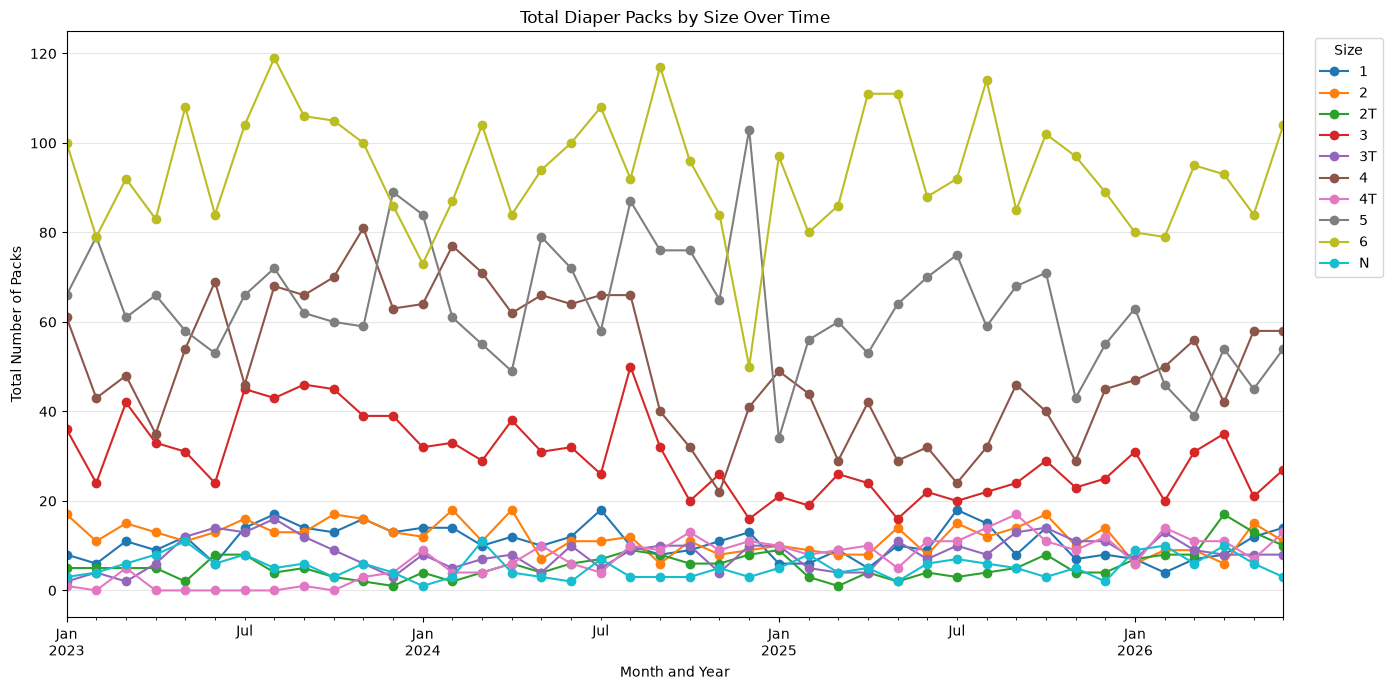

In [54]:
pivot_by_size = pivot.copy().fillna(0)
pivot_by_size.index = pd.to_datetime(
    [f"{int(year)}-{int(month):02d}-01" for year, month in pivot_by_size.index]
)

ax = pivot_by_size.plot(figsize=(14, 7), marker="o")
ax.set_title("Total Diaper Packs by Size Over Time")
ax.set_xlabel("Month and Year")
ax.set_ylabel("Total Number of Packs")
ax.legend(title="Size", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.figure.tight_layout()

Size ratios for each month

In [55]:
monthly_size_ratios = pivot.fillna(0).div(pivot.fillna(0).sum(axis=1), axis=0)

Area chart of size ratios

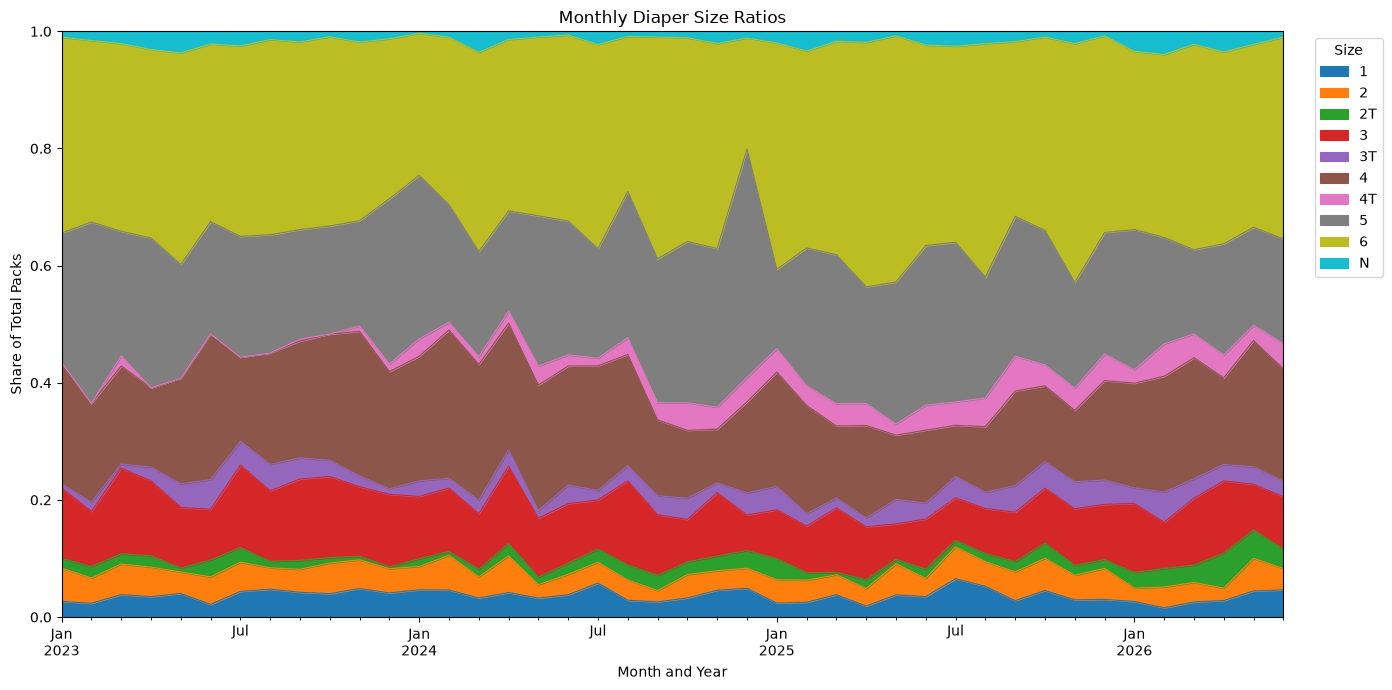

In [56]:
monthly_size_ratios_plot = monthly_size_ratios.copy()
monthly_size_ratios_plot.index = pd.to_datetime(
    [f"{int(year)}-{int(month):02d}-01" for year, month in monthly_size_ratios_plot.index]
)

ax = monthly_size_ratios_plot.plot.area(figsize=(14, 7), linewidth=0.8)
ax.set_title("Monthly Diaper Size Ratios")
ax.set_xlabel("Month and Year")
ax.set_ylabel("Share of Total Packs")
ax.set_ylim(0, 1)
ax.legend(title="Size", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.margins(x=0)
ax.figure.tight_layout()

Statistics for size ratios.

In [57]:
monthly_size_ratios.describe()

size,1,2,2T,3,3T,4,4T,5,6,N
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,0.036767,0.041254,0.019903,0.102569,0.029154,0.174833,0.025619,0.222317,0.328957,0.018628
std,0.010888,0.010739,0.011376,0.022832,0.012014,0.043595,0.017555,0.048377,0.044090,0.009413
min,0.015810,0.019417,0.003175,0.060606,0.006689,0.087273,0.000000,0.135458,0.189394,0.003322
25%,0.028095,0.034592,0.013008,0.084559,0.018972,0.137682,0.012750,0.187150,0.306347,0.009959
50%,0.037987,0.039848,0.017483,0.101118,0.027923,0.182738,0.028931,0.210045,0.328781,0.018210
75%,0.045133,0.050291,0.025883,0.120027,0.039350,0.205985,0.039564,0.253178,0.348247,0.022512
max,0.065455,0.062718,0.059859,0.146341,0.051383,0.253289,0.059649,0.390152,0.420455,0.039526


Box plot of proportions for each size.

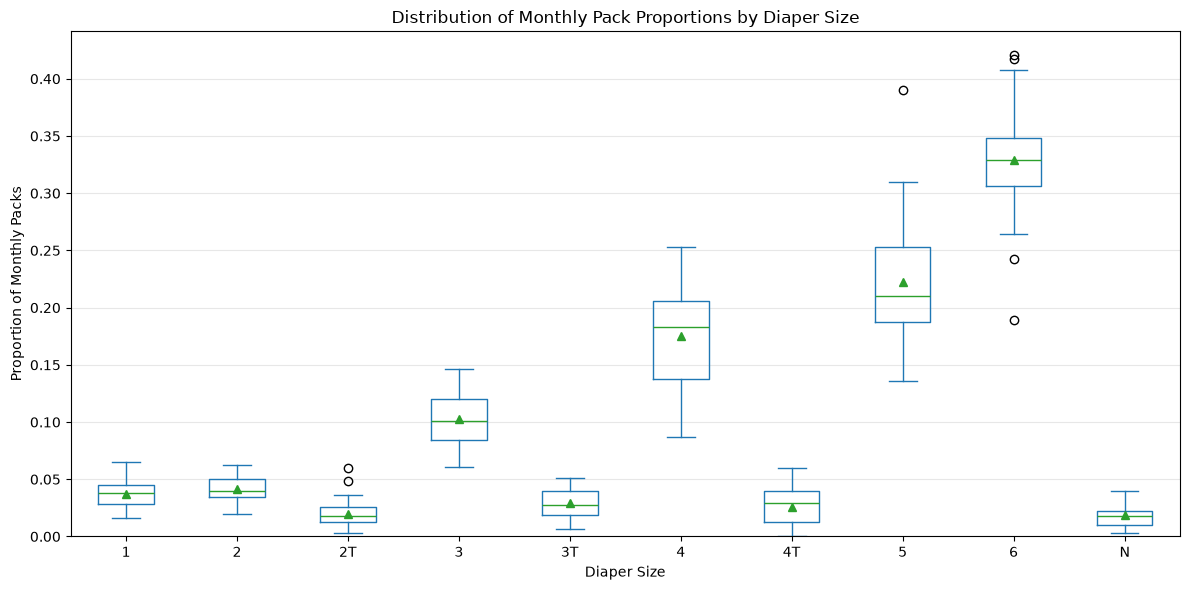

In [58]:
ax = monthly_size_ratios.plot.box(figsize=(12, 6), showmeans=True)
ax.set_title("Distribution of Monthly Pack Proportions by Diaper Size")
ax.set_xlabel("Diaper Size")
ax.set_ylabel("Proportion of Monthly Packs")
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3)
ax.figure.tight_layout()

Chi-square test of homogeneity / independence for ratios.

In [59]:
from scipy.stats import chi2_contingency

# Chi-square requires observed frequencies, so use the monthly pack counts.
observed_counts = pivot.fillna(0).copy()
observed_counts = observed_counts.loc[
    observed_counts.sum(axis=1).gt(0), observed_counts.sum(axis=0).gt(0)
]

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(observed_counts)

In [60]:
expected_counts = pd.DataFrame(
    expected, index=observed_counts.index, columns=observed_counts.columns
)


In [61]:
alpha = 0.05
chi_square_results = pd.Series({
    "chi-square statistic": chi2,
    "degrees of freedom": degrees_of_freedom,
    "p-value": p_value,
    "minimum expected count": expected_counts.to_numpy().min(),
    "expected cells below 5": (expected_counts < 5).to_numpy().sum(),
    "reject null hypothesis (alpha=0.05)": p_value < alpha,
})

display(chi_square_results.to_frame("value"))
if p_value < alpha:
    print("Reject H0: diaper-size ratios are not homogeneous across months.")
else:
    print("Fail to reject H0: there is insufficient evidence that diaper-size ratios differ across months.")

,value
chi-square statistic,777.130308
degrees of freedom,369
p-value,0.0
minimum expected count,4.315518
expected cells below 5,22
reject null hypothesis (alpha=0.05),True


Reject H0: diaper-size ratios are not homogeneous across months.


Main Idea: Test if size ratios are consistent with Chi-Square

Chi-square goodness-of-fit tests using the combined three-year size ratios as the expected distribution.

In [62]:
from scipy.stats import chisquare

annual_size_counts = pivot.fillna(0).groupby(level="year").sum()
annual_size_counts = annual_size_counts.loc[:, annual_size_counts.sum(axis=0).gt(0)]
annual_size_ratios = annual_size_counts.div(annual_size_counts.sum(axis=1), axis=0)

three_year_size_totals = annual_size_counts.sum(axis=0)
three_year_size_ratios = three_year_size_totals / three_year_size_totals.sum()

size_ratio_summary = annual_size_ratios.copy()
size_ratio_summary.loc["All three years"] = three_year_size_ratios
display(size_ratio_summary.style.format("{:.2%}"))

goodness_of_fit_results = []
for year, observed in annual_size_counts.iterrows():
    expected = three_year_size_ratios * observed.sum()
    statistic, p_value = chisquare(f_obs=observed, f_exp=expected)
    goodness_of_fit_results.append({
        "year": int(year),
        "chi-square statistic": statistic,
        "degrees of freedom": len(observed) - 1,
        "p-value": p_value,
        "minimum expected count": expected.min(),
        "reject null hypothesis (alpha=0.05)": p_value < 0.05,
    })

goodness_of_fit_results = pd.DataFrame(goodness_of_fit_results).set_index("year")
display(goodness_of_fit_results)

size,1,2,2T,3,3T,4,4T,5,6,N
year,,,,,,,,,,
2023,3.81%,4.60%,1.45%,12.24%,2.71%,19.28%,0.38%,21.67%,31.94%,1.92%
2024,3.95%,3.76%,1.96%,10.23%,2.52%,18.81%,2.66%,24.24%,30.52%,1.35%
2025,3.63%,4.38%,1.61%,8.55%,3.41%,13.91%,4.01%,22.33%,36.34%,1.83%
2026,3.17%,3.41%,3.84%,10.05%,3.23%,18.94%,3.78%,18.33%,32.58%,2.68%
All three years,3.72%,4.13%,1.97%,10.37%,2.91%,17.68%,2.48%,22.15%,32.77%,1.83%


,chi-square statistic,degrees of freedom,p-value,minimum expected count,reject null hypothesis (alpha=0.05)
year,,,,,
2023,91.033804,9,1.009603e-15,66.762530,True
2024,23.810591,9,4.611024e-03,65.244784,True
2025,83.331594,9,3.511372e-14,57.966919,True
2026,63.181984,9,3.252704e-10,30.025767,True


Fill in missing sizes.

In [ ]:
# Start with the observed monthly pack totals for each known diaper size.
monthly_size_packs_filled = pivot.fillna(0).reindex(
    columns=three_year_size_ratios.index, fill_value=0
)

# Total the packs with a missing size in each month.
missing_size_packs_by_month = (
    wr.loc[wr["size"].isna()]
    .groupby(["year", "month"])["packs"]
    .sum()
    .reindex(monthly_size_packs_filled.index, fill_value=0)
)

# Allocate each month's missing-size packs using the combined three-year ratios.
estimated_missing_size_packs = pd.DataFrame(
    missing_size_packs_by_month.to_numpy()[:, None]
    * three_year_size_ratios.to_numpy()[None, :],
    index=monthly_size_packs_filled.index,
    columns=three_year_size_ratios.index,
)
monthly_size_packs_filled = monthly_size_packs_filled.add(
    estimated_missing_size_packs, fill_value=0
)

size           1     2    2T     3    3T     4    4T      5      6     N
year month                                                              
2023 1      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     2      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     3      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     4      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     5      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     6      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     7      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     8      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     9      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     10     0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     11     0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     12     0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
2024 1      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     2      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     3      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     4      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     5      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00
     6      1.15  1.28  0.61  3.22  0.90  5.48  0.77   6.87  10.16  0.57
     7      1.49  1.65  0.79  4.15  1.16  7.07  0.99   8.86  13.11  0.73
     8      1.71  1.90  0.91  4.77  1.34  8.13  1.14  10.19  15.07  0.84
     9      1.15  1.28  0.61  3.22  0.90  5.48  0.77   6.87  10.16  0.57
     10     1.56  1.74  0.83  4.36  1.22  7.43  1.04   9.30  13.76  0.77
     11     0.89  0.99  0.47  2.49  0.70  4.24  0.59   5.32   7.86  0.44
     12     0.63  0.70  0.33  1.76  0.49  3.01  0.42   3.77   5.57  0.31
2025 1      0.71  0.78  0.37  1.97  0.55  3.36  0.47   4.21   6.23  0.35
     2      1.08  1.20  0.57  3.01  0.84  5.13  0.72   6.42   9.50  0.53
     3      0.52  0.58  0.28  1.45  0.41  2.48  0.35   3.10   4.59  0.26
     4      1.04  1.16  0.55  2.90  0.81  4.95  0.69   6.20   9.17  0.51
     5      0.97  1.07  0.51  2.70  0.76  4.60  0.64   5.76   8.52  0.48
     6      0.67  0.74  0.35  1.87  0.52  3.18  0.45   3.99   5.90  0.33
     7      0.82  0.91  0.43  2.28  0.64  3.89  0.54   4.87   7.21  0.40
     8      1.08  1.20  0.57  3.01  0.84  5.13  0.72   6.42   9.50  0.53
     9      1.00  1.12  0.53  2.80  0.79  4.77  0.67   5.98   8.85  0.49
     10     1.30  1.45  0.69  3.63  1.02  6.19  0.87   7.75  11.47  0.64
     11     0.89  0.99  0.47  2.49  0.70  4.24  0.59   5.32   7.86  0.44
     12     0.85  0.95  0.45  2.39  0.67  4.07  0.57   5.09   7.54  0.42
2026 1      1.15  1.28  0.61  3.22  0.90  5.48  0.77   6.87  10.16  0.57
     2      0.07  0.08  0.04  0.21  0.06  0.35  0.05   0.44   0.66  0.04
     3      0.07  0.08  0.04  0.21  0.06  0.35  0.05   0.44   0.66  0.04
     4      0.04  0.04  0.02  0.10  0.03  0.18  0.02   0.22   0.33  0.02
     5      0.26  0.29  0.14  0.73  0.20  1.24  0.17   1.55   2.29  0.13
     6      0.00  0.00  0.00  0.00  0.00  0.00  0.00   0.00   0.00  0.00

In [77]:
estimated_missing_size_packs_by_date = estimated_missing_size_packs.copy()
estimated_missing_size_packs_by_date.index = pd.to_datetime(
    [
        f"{int(year)}-{int(month):02d}-01"
        for year, month in estimated_missing_size_packs_by_date.index
    ]
)

adjusted_pivot_by_size = pivot_by_size.add(
    estimated_missing_size_packs_by_date, fill_value=0
)
display(adjusted_pivot_by_size.round(2).head())

size,1,2,2T,3,3T,4,4T,5,6,N
2023-01-01,8.0,17.0,5.0,36.0,2.0,61.0,1.0,66.0,100.0,3.0
2023-02-01,6.0,11.0,5.0,24.0,4.0,43.0,0.0,79.0,79.0,4.0
2023-03-01,11.0,15.0,5.0,42.0,2.0,48.0,5.0,61.0,92.0,6.0
2023-04-01,9.0,13.0,5.0,33.0,6.0,35.0,0.0,66.0,83.0,8.0
2023-05-01,12.0,11.0,2.0,31.0,12.0,54.0,0.0,58.0,108.0,11.0


### 3b. Diaper Packs Analysis

In [64]:
wr.head()

,timestamp,branch,zip,size,packs,year,month
0,2023-01-03,WR,63118,4,1.0,2023,1
1,2023-01-03,WR,63043,5,1.0,2023,1
2,2023-01-03,WR,63123,6,2.0,2023,1
3,2023-01-03,WR,63123,1,1.0,2023,1
4,2023-01-03,WR,63123,3,2.0,2023,1


Pivot table for totals.

In [65]:
pivot = pd.pivot_table(wr, values='packs', index=['year', 'month'], aggfunc='sum')

Line graph for each year.

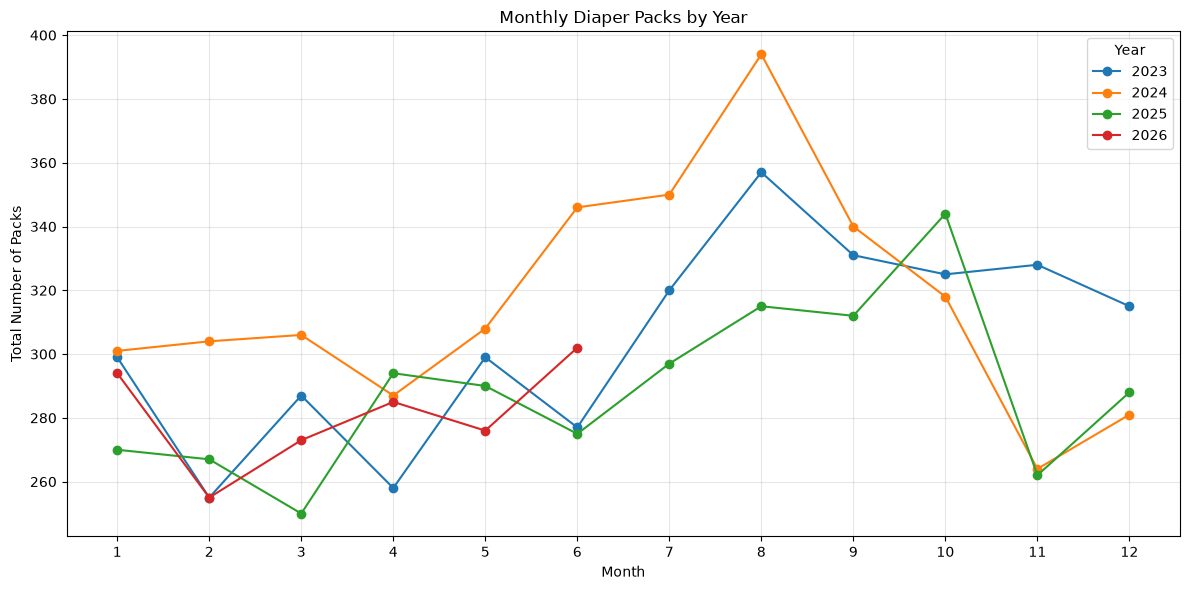

In [66]:
packs_by_month_year = pivot["packs"].unstack(level="year")
packs_by_month_year.columns = packs_by_month_year.columns.astype(int)

ax = packs_by_month_year.plot(figsize=(12, 6), marker="o")
ax.set_title("Monthly Diaper Packs by Year")
ax.set_xlabel("Month")
ax.set_ylabel("Total Number of Packs")
ax.set_xticks(range(1, 13))
ax.legend(title="Year")
ax.grid(alpha=0.3)
ax.figure.tight_layout()

## 4. Predictive Modeling

### 4a. Estimating Diaper Totals

Main idea: Since there is a seasonal trand, use Holt-Winters Exponential Smoothing to predict totals.

### 4b. Estimating Diaper Size Totals

Main idea: number of size N diapers distributed in a month = size N proportion * estimated monthly total

## 5. Evaluating Models

### 5a. Diaper Totals Predictions

Main idea: Find the error in the model's predictions. Compare to 2026 data so far, or maybe validate on 2025 data.

### 5b. Diaper Size Totals Predictions

Main idea: Find the error in the model's predictions. Compare to 2026 data so far, or maybe validate on 2025 data.

## 6. Conclusions

Answer the following questions:
- What did I find out in exploratory analysis?
- How well did the models predict the test set?